# The retail story, as formulas

**Week 1, Monday. The story that opens the day: one Saturday at Kalpa Retail, walked from a
shopping basket to the metrics every later chapter uses.**

Most of us have shopped in a store and on an app and never seen the business from the other
side of the till. This notebook takes one scene from the morning's story, a Retail-Plus
member's basket on a Saturday, and turns it into the metrics a retail data team is asked for,
each as a formula. Every number in this notebook is **invented**: they are the round
illustrative numbers of the domain dossier, chosen so the arithmetic is easy, and none of them
is Kalpa's data or any real company's. Kalpa's own orders arrive in chapter 1.

The formulas are the ten on the domain card,
`cheatsheets/C2_W01_D01_retail_domain_card_STUDENT.pdf`, and the long version of each is in
the dossier, `study-notes/C2_W01_D01_domain_retail_STUDENT.md`, sections 3 and 5.

> **Kavya's review.** Before I read any number, I read three things beside it: what it is
> divided by, over which window, and who asked for it. This notebook is where you practise
> saying all three.

**Setup.** The first cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`. This notebook needs no data file, since its numbers are
invented and typed in.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
print("helper loaded; every number below is invented")

helper loaded; every number below is invented


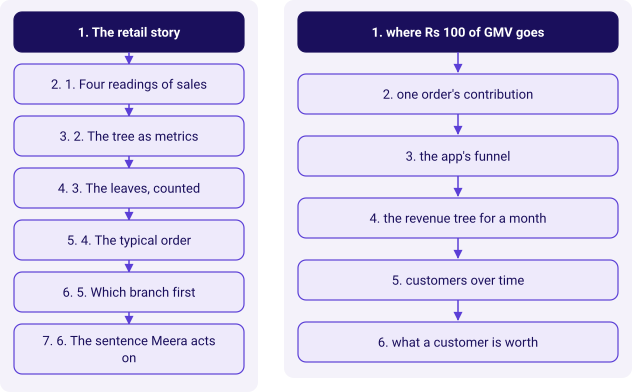

In [2]:
kit.side_by_side(
    kit.ladder(['The retail story', '1. Four readings of sales', '2. The tree as metrics', '3. The leaves, counted', '4. The typical order', '5. Which branch first', '6. The sentence Meera acts on'], lit=0, show=False),
    kit.vflow(['1. where Rs 100 of GMV goes', "2. one order's contribution", "3. the app's funnel", '4. the revenue tree for a month', '5. customers over time', '6. what a customer is worth'], lit=0, show=False),
)

## 1. Rs 100 of GMV leaves Rs 2.50 of operating profit

The member's basket shows Rs 1,800 at the checkout. Gross merchandise value (GMV) is everything
customers ordered at the price charged; the profit and loss statement walks it down, one
deduction at a time. On Rs 100 of invented GMV: Rs 4 is cancelled and Rs 6 returned, Rs 10 is
GST collected for the government, Rs 60 pays for the goods, Rs 12.50 is spent per order on
delivery, returns, payment fees and marketing, and Rs 5 pays the fixed costs.

**Predict before you run.** Of Rs 100 ordered, how much is left as operating profit?

- a) About Rs 25, the gross margin.
- b) About Rs 10, what a shop keeps after tax.
- c) Rs 2.50.
- d) Nothing, since retail runs at a loss.

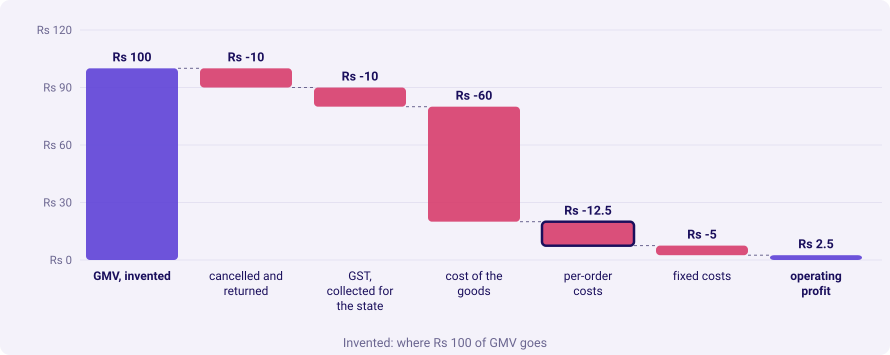

line,Rs left of 100
kept,90
net revenue,80
gross margin,20
contribution,7.5
operating profit,2.5


In [3]:
gmv = 100.0                               # invented, the dossier's illustrative Rs 100
steps = [("cancelled and returned", -10), ("GST, collected for the state", -10),
         ("cost of the goods", -60), ("per-order costs", -12.5), ("fixed costs", -5)]
left = gmv
levels = {}
names = ["kept", "net revenue", "gross margin", "contribution", "operating profit"]
for (label, change), name in zip(steps, names):
    left += change
    levels[name] = left
kit.bridge(("GMV, invented", gmv), steps, end_label="operating profit", lit=(3,),
           fmt=lambda v: f"Rs {v:g}", title="Invented: where Rs 100 of GMV goes")
kit.table(["line", "Rs left of 100"], [(n, f"{v:g}") for n, v in levels.items()],
          caption="Invented numbers, the dossier's walk from GMV to operating profit")

**What happened.** The answer is c. Net revenue is Rs 80, gross margin Rs 20 (25 percent of
net revenue), contribution Rs 7.50 and operating profit Rs 2.50. A retailer keeps a thin
slice, which is why a price cut that brings no extra volume can give away the whole profit.

In [4]:
kit.check("net revenue is Rs 80 of every Rs 100 of GMV", levels["net revenue"] == 80)
kit.check("gross margin is 25 percent of net revenue",
          levels["gross margin"] / levels["net revenue"] == 0.25)
kit.check("operating profit is Rs 2.50", levels["operating profit"] == 2.5)

## 2. One order's contribution is Rs 150 of the Rs 1,800 paid

Contribution is gross margin less the costs that come with each order: picking and delivery,
the payment fee, the expected cost of returns and the marketing that brought the order. It is
what the order adds towards the costs that do not change with one more order.

**Predict before you run.** The member paid Rs 1,800. What does the order contribute?

- a) Rs 1,800, what the member paid.
- b) Rs 150.
- c) Rs 400, the gross margin.
- d) Rs 1,600, the net revenue.

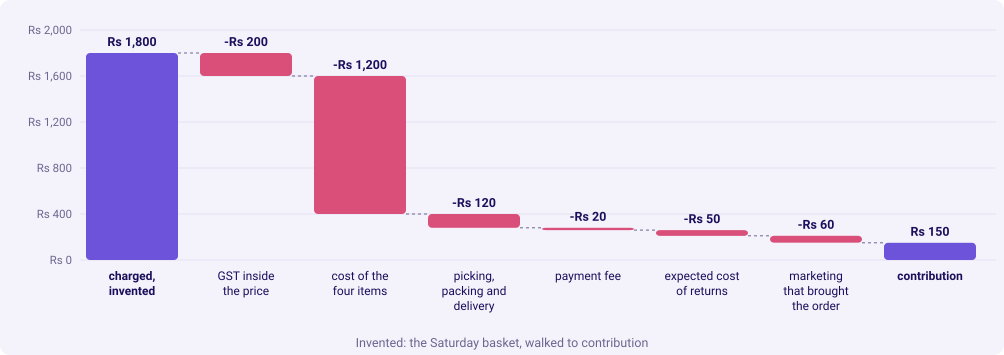

net revenue Rs 1,600, gross margin Rs 400 (25%), contribution Rs 150 (9.4% of net revenue)


In [5]:
basket = {"charged at checkout": 1800, "GST inside the price": -200, "cost of the four items": -1200,
          "picking, packing and delivery": -120, "payment fee": -20,
          "expected cost of returns": -50, "marketing that brought the order": -60}  # invented
net_revenue = basket["charged at checkout"] + basket["GST inside the price"]
gross_margin = net_revenue + basket["cost of the four items"]
contribution = gross_margin + sum(v for k, v in basket.items()
                                  if k not in ("charged at checkout", "GST inside the price",
                                               "cost of the four items"))
kit.bridge(("charged, invented", 1800), [(k, v) for k, v in basket.items() if v < 0],
           end_label="contribution", title="Invented: the Saturday basket, walked to contribution")
print(f"net revenue {kit.rupees(net_revenue)}, gross margin {kit.rupees(gross_margin)} "
      f"({gross_margin / net_revenue:.0%}), contribution {kit.rupees(contribution)} "
      f"({contribution / net_revenue:.1%} of net revenue)")

In [6]:
kit.check("gross margin percent = (net revenue less COGS) / net revenue = 25 percent",
          gross_margin / net_revenue == 0.25, f"{gross_margin / net_revenue:.0%}")
kit.check("contribution on the basket is Rs 150", contribution == 150, kit.rupees(contribution))

**What happened.** The answer is b. Delivery costs about the same whatever is in the bag, so a
small basket carries the same trip on far less margin; that is the arithmetic behind a minimum
order for free delivery.

## 3. Conversion depends on what you divide by

On the invented Saturday the app had 50,000 visitors, 80,000 sessions, 8,000 carts and 2,000
orders. Conversion is orders over visits in the same window, and "visits" has more than one
honest reading.

**Predict before you run.** Which conversion is right: orders over sessions, or orders over
visitors?

- a) Over sessions, 2.5 percent, because sessions are what the app counts.
- b) Over visitors, 4.0 percent, because visitors are people.
- c) Either, as long as the denominator is named and kept the same across periods.
- d) Neither, because carts are the real visits.

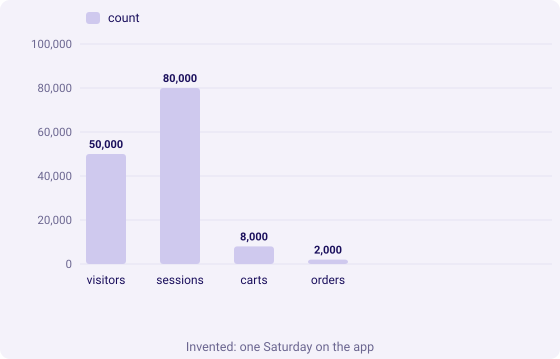

conversion,value
orders / sessions,2.5%
orders / visitors,4.0%
orders / carts,25.0%


In [7]:
funnel = [("visitors", 50000), ("sessions", 80000), ("carts", 8000), ("orders", 2000)]  # invented
f = dict(funnel)
rates = [("orders / sessions", f["orders"] / f["sessions"]),
         ("orders / visitors", f["orders"] / f["visitors"]),
         ("orders / carts", f["orders"] / f["carts"])]
kit.columns([n for n, _ in funnel], [("count", [v for _, v in funnel])], width=560,
            title="Invented: one Saturday on the app")
kit.table(["conversion", "value"], [(n, f"{r:.1%}") for n, r in rates],
          caption="Three honest conversions on the same Saturday")
kit.check("conversion over sessions is 2.5 percent", rates[0][1] == 0.025)
kit.check("conversion over visitors is 4.0 percent", rates[1][1] == 0.04)

**What happened.** The answer is c. All three are correct arithmetic; they measure different
things. An app update that starts new sessions sooner cuts conversion over sessions with no
change in buyers, which is a denominator that shifted, the first trap on the card.

## 4. Revenue is a tree, and the leaks come off it

For the invented month, 40,000 customers placed 1.25 orders each, of four items, at Rs 450 an
item, before a 10 percent discount. The tree multiplies them. Returns and cancellations then
leak out of what the tree produced, and the leaks can grow faster than the revenue.

**Predict before you run.** Next month revenue rises 10 percent while returns climb from 6 to
12 percent of it. How much more does Kalpa keep?

- a) 10 percent more, since revenue rose 10 percent.
- b) About 3 percent more.
- c) 4 percent more, 10 less the 6 points of extra returns.
- d) Less than before.

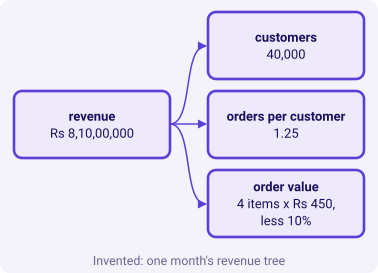

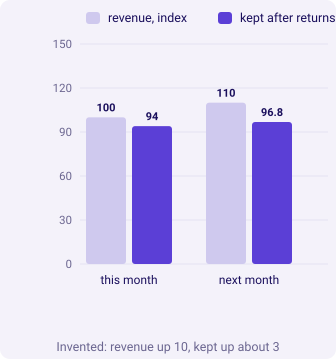

kept: 94 then 96.8, up 3.0%


In [8]:
month = {"customers": 40000, "orders per customer": 1.25, "items per order": 4,
         "price per item": 450, "kept after discount": 0.90}                # invented
revenue = 1.0
for v in month.values():
    revenue *= v
kit.driver_tree({"label": "revenue", "note": kit.rupees(revenue), "kind": "known", "children": [
    {"label": "customers", "note": "40,000", "kind": "known"},
    {"label": "orders per customer", "note": "1.25", "kind": "known"},
    {"label": "order value", "note": "4 items x Rs 450, less 10%", "kind": "known"}]},
    title="Invented: one month's revenue tree")
kept_before = 100 * (1 - 0.06)                                          # invented index
kept_after = 110 * (1 - 0.12)
kit.columns(["this month", "next month"], [("revenue, index", [100, 110]), ("kept after returns", [kept_before, kept_after])],
            fmt=lambda v: f"{v:g}", title="Invented: revenue up 10, kept up about 3")
print(f"kept: {kept_before:g} then {kept_after:g}, up {kept_after / kept_before - 1:.1%}")
kit.check("the tree multiplies to Rs 8.1 crore", round(revenue) == 81000000, kit.rupees(revenue))
kit.check("what Kalpa keeps rises about 3 percent", round(kept_after / kept_before - 1, 2) == 0.03)

**What happened.** The answer is b: 100 less 6 is 94, and 110 less 13.2 is 96.8, up about 3
percent. A growth figure has to say which side of the leaks it was measured on, which is the
question chapter 1 asks of Kalpa's own orders.

## 5. Retention divides by the cohort, never by the survivors

January brought 1,000 new customers (invented). 380 ordered in February, 300 in March and
260 in April. Retention in month k is the cohort's buyers in month k over the cohort's
starting size.

**The plausible wrong answer.** A hurried analyst divides March's 300 by February's 380 and
reports 79 percent retention.

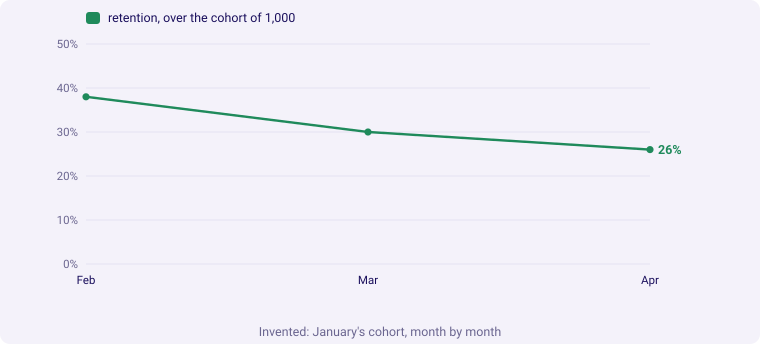

March retention: 30% over the cohort; 79% over the survivors


In [9]:
cohort = 1000                                                     # invented
buyers = {"Feb": 380, "Mar": 300, "Apr": 260}
right = {m: b / cohort for m, b in buyers.items()}
hurried_march = buyers["Mar"] / buyers["Feb"]
kit.line(list(buyers), [("retention, over the cohort of 1,000", [round(r * 100) for r in right.values()], "good")],
         fmt=lambda v: f"{v:g}%", title="Invented: January's cohort, month by month")
print(f"March retention: {right['Mar']:.0%} over the cohort; {hurried_march:.0%} over the survivors")
kit.check("March retention over the cohort is 30 percent", right["Mar"] == 0.30)
kit.check("the survivor division reads 79 percent", round(hurried_march * 100) == 79)

**Why it is wrong.** 79 percent answers "of February's buyers, how many bought again", a
different metric. Reported as retention it tells the head of Retail-Plus that the tier holds
four in five customers when it holds three in ten.

## 6. A customer is worth contribution, and the budget pays back from it

Customer lifetime value, simply: contribution per order, times orders a year, times years as a
customer. Customer acquisition cost (CAC) is acquisition spend over the new customers it
brought, and payback is CAC over monthly contribution per customer. On invented numbers:
Rs 150 of contribution per order, 6 orders a year, 2 years, and Rs 12 crore bringing 80,000
new customers.

**Predict before you run.** How many months does one new customer take to pay back their
acquisition cost?

- a) One month, since one order of Rs 1,600 covers Rs 1,500.
- b) 20 months.
- c) 12 months, one year of orders.
- d) Never, since contribution is below CAC.

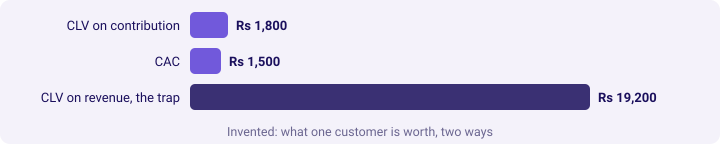

CLV Rs 1,800, CAC Rs 1,500, payback 20 months


In [10]:
per_order, per_year, years = 150, 6, 2                            # invented
clv = per_order * per_year * years
clv_on_revenue = 1600 * per_year * years
cac = 12_00_00_000 / 80000
monthly = per_order * per_year / 12
payback = cac / monthly
kit.bars([("CLV on contribution", clv), ("CAC", cac), ("CLV on revenue, the trap", clv_on_revenue)],
         fmt=kit.rupees, lit=(2,), title="Invented: what one customer is worth, two ways")
print(f"CLV {kit.rupees(clv)}, CAC {kit.rupees(cac)}, payback {payback:.0f} months")
kit.check("CLV on contribution is Rs 1,800", clv == 1800)
kit.check("CAC is Rs 1,500", cac == 1500)
kit.check("payback is 20 months", payback == 20)

**What happened.** The answer is b. Rs 75 of contribution a month repays Rs 1,500 in 20 months,
leaving Rs 300 of the Rs 1,800 lifetime value. Valued on revenue the same customer reads
Rs 19,200, more than ten times too high, and every acquisition budget sized on it is too
large. Option a pays the CAC out of revenue, which is the same mistake in one line.

### The card's other three formulas

Inventory days, gross margin, and like-for-like growth each carry a trap the card names. The
cell computes all three on invented numbers.

metric,formula,invented result,the trap
inventory days,stock at cost / COGS per day,45 days,stock at selling price inflates the days
gross margin,(net revenue less COGS) / net revenue,25%,"divided by GMV it reads 22%, and GST moves it"
like-for-like growth,"both-year stores' sales / last year's, less 1",2%,total growth with 20 new stores reads 15%


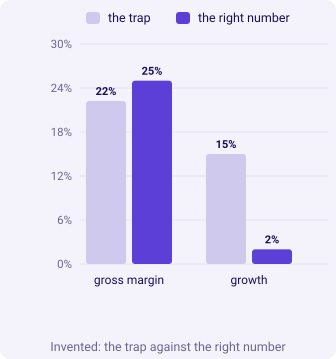

In [11]:
inventory_days = 45_00_000 / 1_00_000                                  # invented
margin, net, gmv = 400, 1600, 1800                                      # the invented basket
on_net, on_gmv = margin / net, margin / gmv
total_growth = (510 + 65) / 500 - 1                                     # invented, Rs crore
like_for_like = 510 / 500 - 1
kit.table(["metric", "formula", "invented result", "the trap"],
          [("inventory days", "stock at cost / COGS per day", f"{inventory_days:.0f} days",
            "stock at selling price inflates the days"),
           ("gross margin", "(net revenue less COGS) / net revenue", f"{on_net:.0%}",
            f"divided by GMV it reads {on_gmv:.0%}, and GST moves it"),
           ("like-for-like growth", "both-year stores' sales / last year's, less 1",
            f"{like_for_like:.0%}", f"total growth with 20 new stores reads {total_growth:.0%}")],
          caption="Invented numbers for the card's last three formulas")
kit.columns(["gross margin", "growth"], [("the trap", [on_gmv * 100, total_growth * 100]),
                                         ("the right number", [on_net * 100, like_for_like * 100])],
            fmt=lambda v: f"{v:.0f}%", title="Invented: the trap against the right number")
kit.check("margin on net revenue is 25 percent, on GMV 22", (round(on_net, 2), round(on_gmv, 2)) == (0.25, 0.22))
kit.check("like-for-like growth is 2 percent against 15 total", (round(like_for_like, 2), round(total_growth, 2)) == (0.02, 0.15))

### In the interview

**[S] How does a retailer make money, and why is a marketplace's GMV not its revenue?** "A
retailer buys goods and sells them at a margin: GMV less cancellations, returns and GST is net
revenue, less the cost of goods is gross margin, less per-order costs is contribution, less
fixed costs is operating profit, and real retailers keep a few rupees in a hundred. A
marketplace does not own the goods, so the GMV it shows is its sellers' sales and its revenue
is only the fees it charges them."

**[S] Define average order value, conversion and repeat rate, and say what each is divided
by.** "Average order value is revenue over orders; conversion is orders over visits, sessions
or visitors, whichever is named, in the same window; repeat rate is customers with two or more
orders over customers who ordered. I say the denominator and the window before the number,
because each metric changes meaning when either moves."

## What the story established

In [12]:
kit.table(["formula", "invented worked number", "who asks"],
          [("net revenue = GMV less cancellations, returns, GST", "Rs 80 of Rs 100", "the finance controller"),
           ("contribution = gross margin less per-order costs", "Rs 150 on Rs 1,800", "the finance controller"),
           ("conversion = orders / visits, same window", "2.5% of sessions", "marketing"),
           ("revenue = customers x orders per customer x order value", "Rs 8.1 crore; kept up 3% on 10%", "the CEO"),
           ("retention = cohort buyers in month k / cohort size", "30% in March", "the head of Retail-Plus"),
           ("payback = CAC / monthly contribution per customer", "20 months", "the CEO, before signing")],
          caption="The story's formulas; every number invented")
kit.check_summary()
print("Next: chapter 1 opens Kalpa's own 30 orders and asks which total is 'sales'.")

formula,invented worked number,who asks
"net revenue = GMV less cancellations, returns, GST",Rs 80 of Rs 100,the finance controller
contribution = gross margin less per-order costs,"Rs 150 on Rs 1,800",the finance controller
"conversion = orders / visits, same window",2.5% of sessions,marketing
revenue = customers x orders per customer x order value,Rs 8.1 crore; kept up 3% on 10%,the CEO
retention = cohort buyers in month k / cohort size,30% in March,the head of Retail-Plus
payback = CAC / monthly contribution per customer,20 months,"the CEO, before signing"


Next: chapter 1 opens Kalpa's own 30 orders and asks which total is 'sales'.
